<a href="https://colab.research.google.com/github/abhiram123467/gsoc2026-ml4sci-artextract/blob/main/artextractevaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.models as models
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import timm

# 1. Strict Device Setup
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Image Transformations
IMG_SIZE = 224
# Standard ImageNet stats
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=mean.tolist(), std=std.tolist())
])

# 3. Safe Visualization Helper
def imshow_safe(tensor, title=None):
    """Safely denormalizes and plots a tensor to ensure data is not corrupted."""
    image = tensor.cpu().clone()
    image = image.squeeze(0) if image.dim() == 4 else image

    # Denormalize: image = image * std + mean
    for t, m, s in zip(image, mean, std):
        t.mul_(s).add_(m)

    image = image.clamp(0, 1).permute(1, 2, 0).numpy()
    plt.imshow(image)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

# Example usage (assuming local dataset structure):
# dataset = ImageFolder('data/wikiart/train', transform=train_transform)
# dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [2]:
class ArtExtractCNNRNN(nn.Module):
    def __init__(self, n_styles, n_artists, n_genres, lstm_hidden=512):
        super().__init__()

        # CNN Backbone: ResNet50 (removing the final pooling and FC layers)
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        self.backbone = nn.Sequential(*list(resnet.children())[:-2])

        # Projection to reduce dimensions before LSTM
        self.proj = nn.Conv2d(2048, lstm_hidden, kernel_size=1)

        # BiLSTM for spatial sequence modeling
        self.lstm = nn.LSTM(
            input_size=lstm_hidden,
            hidden_size=lstm_hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True
        )

        lstm_out_dim = lstm_hidden * 2

        # Multi-task Classification Heads
        self.style_head = nn.Linear(lstm_out_dim, n_styles)
        self.artist_head = nn.Linear(lstm_out_dim, n_artists)
        self.genre_head = nn.Linear(lstm_out_dim, n_genres)

    def forward(self, x):
        # 1. Extract spatial features: Shape (Batch, 2048, 7, 7)
        features = self.backbone(x)

        # 2. Project down: Shape (Batch, 512, 7, 7)
        features = self.proj(features)

        # 3. Flatten spatial dimensions for sequence: Shape (Batch, 49, 512)
        batch_size = features.size(0)
        seq_features = features.view(batch_size, 512, -1).permute(0, 2, 1)

        # 4. Pass through BiLSTM
        lstm_out, (hn, cn) = self.lstm(seq_features)

        # 5. Global Average Pooling over the sequence
        context_vector = lstm_out.mean(dim=1)

        # 6. Multi-task predictions
        style_pred = self.style_head(context_vector)
        artist_pred = self.artist_head(context_vector)
        genre_pred = self.genre_head(context_vector)

        # Returning context_vector as the embedding for your t-SNE outlier detection
        return style_pred, artist_pred, genre_pred, context_vector

# Initialization test
task1_model = ArtExtractCNNRNN(n_styles=10, n_artists=20, n_genres=5).to(DEVICE)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 112MB/s]


In [3]:
import torch.nn.functional as F

class SimilaritySiameseNet(nn.Module):
    def __init__(self, embed_dim=256):
        super().__init__()
        # EfficientNet backbone using timm
        self.backbone = timm.create_model('efficientnet_b2', pretrained=True, num_classes=0)

        # Projection head to embedding space
        self.head = nn.Sequential(
            nn.Linear(self.backbone.num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, embed_dim)
        )

    def forward(self, x):
        features = self.backbone(x)
        embeddings = self.head(features)

        # L2 Normalization is mandatory for cosine similarity retrieval
        return F.normalize(embeddings, p=2, dim=1)

# Initialization test
task2_model = SimilaritySiameseNet(embed_dim=256).to(DEVICE)

# Triplet Loss Setup for training
triplet_loss_criterion = nn.TripletMarginLoss(margin=0.3, p=2)

# Pseudo-code for a training step:
# anchor_emb = task2_model(anchor_images)
# pos_emb = task2_model(positive_images)
# neg_emb = task2_model(negative_images)
# loss = triplet_loss_criterion(anchor_emb, pos_emb, neg_emb)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]

In [4]:
import random
from PIL import Image
from torch.utils.data import Dataset

class TripletArtDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        """
        Args:
            image_paths (list of str): Paths to all painting images.
            labels (list of int/str): Corresponding artist or style labels.
            transform: PyTorch vision transforms.
        """
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

        # Group image indices by label for fast positive/negative sampling
        self.label_to_indices = {}
        for idx, label in enumerate(labels):
            if label not in self.label_to_indices:
                self.label_to_indices[label] = []
            self.label_to_indices[label].append(idx)

        # Filter out labels that have only 1 image (impossible to form a positive pair)
        self.valid_labels = [lbl for lbl, indices in self.label_to_indices.items() if len(indices) > 1]

        # Only use indices belonging to valid labels as anchors
        self.valid_indices = [idx for idx, lbl in enumerate(labels) if lbl in self.valid_labels]

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        # 1. ANCHOR
        anchor_idx = self.valid_indices[idx]
        anchor_label = self.labels[anchor_idx]
        anchor_img = Image.open(self.image_paths[anchor_idx]).convert('RGB')

        # 2. POSITIVE (Same artist/style, but a different image)
        positive_idx = anchor_idx
        while positive_idx == anchor_idx:
            positive_idx = random.choice(self.label_to_indices[anchor_label])
        positive_img = Image.open(self.image_paths[positive_idx]).convert('RGB')

        # 3. NEGATIVE (Completely different artist/style)
        negative_label = anchor_label
        while negative_label == anchor_label:
            negative_label = random.choice(self.valid_labels)
        negative_idx = random.choice(self.label_to_indices[negative_label])
        negative_img = Image.open(self.image_paths[negative_idx]).convert('RGB')

        # 4. Apply transforms
        if self.transform:
            anchor_img = self.transform(anchor_img)
            positive_img = self.transform(positive_img)
            negative_img = self.transform(negative_img)

        return anchor_img, positive_img, negative_img

# --- Example Usage ---
# Assuming you have `sim_transform` defined from earlier
# my_triplet_dataset = TripletArtDataset(paths_list, labels_list, transform=sim_transform)
# triplet_loader = DataLoader(my_triplet_dataset, batch_size=16, shuffle=True)

In [7]:
import pandas as pd
import requests
from PIL import Image
from io import BytesIO
from tqdm import tqdm
import torchvision.transforms as T

# 1. Define the image transformations for the Siamese Network
IMG_SIZE_SIM = 224
sim_transform = T.Compose([
    T.Resize((IMG_SIZE_SIM, IMG_SIZE_SIM)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 2. Download the NGA Metadata
print("Downloading NGA metadata...")
url = "https://raw.githubusercontent.com/NationalGalleryOfArt/opendata/main/data/objects.csv"
nga_df = pd.read_csv(url, low_memory=False)

# Filter for oil/canvas paintings with an assigned artist
paintings = nga_df[nga_df['medium'].str.contains('oil|canvas', case=False, na=False)].dropna(subset=['attribution'])

# Keep artists with at least 2 works (required to form an Anchor-Positive pair)
artist_counts = paintings['attribution'].value_counts()
valid_artists = artist_counts[artist_counts >= 2].index
paintings = paintings[paintings['attribution'].isin(valid_artists)]

# 3. Fetch images directly into RAM
nga_samples = []
NGA_IMG_BASE = 'https://api.nga.gov/iiif/{}/full/200,/0/default.jpg'

N_FETCH = 100  # Change this to 500 or 1000 later for full training!
print(f"Fetching up to {N_FETCH} images from NGA API...")

for _, row in tqdm(paintings.iterrows(), total=N_FETCH):
    if len(nga_samples) >= N_FETCH:
        break

    obj_id = row.get('objectid', row.get('id'))
    if pd.isna(obj_id):
        continue

    try:
        resp = requests.get(NGA_IMG_BASE.format(int(obj_id)), timeout=5)
        if resp.status_code == 200:
            img = Image.open(BytesIO(resp.content)).convert('RGB')
            nga_samples.append({
                'image': img,
                'artist': row['attribution'],
                'obj_id': obj_id
            })
    except Exception as e:
        pass # Skip broken links quietly

print(f"Successfully loaded {len(nga_samples)} images into memory!")

Fetching up to 100 images from NGA API...


3675it [20:38,  2.97it/s]

Successfully loaded 0 images into memory!


In [8]:
import pandas as pd
import requests
from PIL import Image
from io import BytesIO
from tqdm import tqdm
import torchvision.transforms as T

# 1. Image transformations
IMG_SIZE_SIM = 224
sim_transform = T.Compose([
    T.Resize((IMG_SIZE_SIM, IMG_SIZE_SIM)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 2. Download BOTH metadata tables
print("Downloading NGA metadata (Objects)...")
objects_url = "https://raw.githubusercontent.com/NationalGalleryOfArt/opendata/main/data/objects.csv"
objects_df = pd.read_csv(objects_url, low_memory=False)

print("Downloading NGA metadata (Images)...")
images_url = "https://raw.githubusercontent.com/NationalGalleryOfArt/opendata/main/data/published_images.csv"
images_df = pd.read_csv(images_url, low_memory=False)

# Merge them: 'objectid' in objects matches 'depictstmsobjectid' in published_images
print("Merging datasets to extract image UUIDs...")
merged_df = pd.merge(objects_df, images_df, left_on='objectid', right_on='depictstmsobjectid')

# Filter for oil/canvas paintings with an assigned artist
paintings = merged_df[merged_df['medium'].str.contains('oil|canvas', case=False, na=False)].dropna(subset=['attribution'])

# Keep artists with at least 2 works
artist_counts = paintings['attribution'].value_counts()
valid_artists = artist_counts[artist_counts >= 2].index
paintings = paintings[paintings['attribution'].isin(valid_artists)]

# 3. Fetch images using the UUID!
nga_samples = []
NGA_IMG_BASE = 'https://api.nga.gov/iiif/{}/full/200,/0/default.jpg'

N_FETCH = 100
print(f"Fetching up to {N_FETCH} images from NGA API...")

for _, row in tqdm(paintings.iterrows(), total=N_FETCH):
    if len(nga_samples) >= N_FETCH:
        break

    image_uuid = row.get('uuid') # Extracted from published_images.csv
    if pd.isna(image_uuid):
        continue

    try:
        # Plug the UUID into the IIIF string
        resp = requests.get(NGA_IMG_BASE.format(image_uuid), timeout=5)
        if resp.status_code == 200:
            img = Image.open(BytesIO(resp.content)).convert('RGB')
            nga_samples.append({
                'image': img,
                'artist': row['attribution'],
                'obj_id': row['objectid']
            })
    except Exception as e:
        pass # Skip broken links quietly

print(f"Successfully loaded {len(nga_samples)} images into memory!")

Merging datasets to extract image UUIDs...
Fetching up to 100 images from NGA API...


3337it [00:00, 19840.18it/s]

Successfully loaded 0 images into memory!


In [9]:
import pandas as pd
import requests
from PIL import Image
from io import BytesIO
from tqdm import tqdm
import torchvision.transforms as T

# 1. Image transformations
IMG_SIZE_SIM = 224
sim_transform = T.Compose([
    T.Resize((IMG_SIZE_SIM, IMG_SIZE_SIM)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 2. Download BOTH metadata tables
print("Downloading NGA metadata (Objects)...")
objects_url = "https://raw.githubusercontent.com/NationalGalleryOfArt/opendata/main/data/objects.csv"
objects_df = pd.read_csv(objects_url, low_memory=False)

print("Downloading NGA metadata (Images)...")
images_url = "https://raw.githubusercontent.com/NationalGalleryOfArt/opendata/main/data/published_images.csv"
images_df = pd.read_csv(images_url, low_memory=False)

# Merge with explicit suffixes to prevent column collision
print("Merging datasets to extract image UUIDs...")
merged_df = pd.merge(
    objects_df,
    images_df,
    left_on='objectid',
    right_on='depictstmsobjectid',
    suffixes=('_obj', '_img') # <--- THE FIX
)

# Filter for oil/canvas paintings with an assigned artist
paintings = merged_df[merged_df['medium'].str.contains('oil|canvas', case=False, na=False)].dropna(subset=['attribution'])

# Keep artists with at least 2 works
artist_counts = paintings['attribution'].value_counts()
valid_artists = artist_counts[artist_counts >= 2].index
paintings = paintings[paintings['attribution'].isin(valid_artists)]

# 3. Fetch images using the specific Image UUID!
nga_samples = []
NGA_IMG_BASE = 'https://api.nga.gov/iiif/{}/full/200,/0/default.jpg'

N_FETCH = 100
print(f"Fetching up to {N_FETCH} images from NGA API...")

for _, row in tqdm(paintings.iterrows(), total=N_FETCH):
    if len(nga_samples) >= N_FETCH:
        break

    # Grab the UUID specifically from the published_images table
    image_uuid = row.get('uuid_img')
    if pd.isna(image_uuid):
        continue

    try:
        resp = requests.get(NGA_IMG_BASE.format(image_uuid), timeout=5)
        if resp.status_code == 200:
            img = Image.open(BytesIO(resp.content)).convert('RGB')
            nga_samples.append({
                'image': img,
                'artist': row['attribution'],
                'obj_id': row['objectid']
            })
    except Exception as e:
        pass

print(f"Successfully loaded {len(nga_samples)} images into memory!")

Merging datasets to extract image UUIDs...
Fetching up to 100 images from NGA API...


100%|██████████| 100/100 [00:43<00:00,  2.32it/s]

Successfully loaded 100 images into memory!


Extracting embeddings for KNN retrieval...


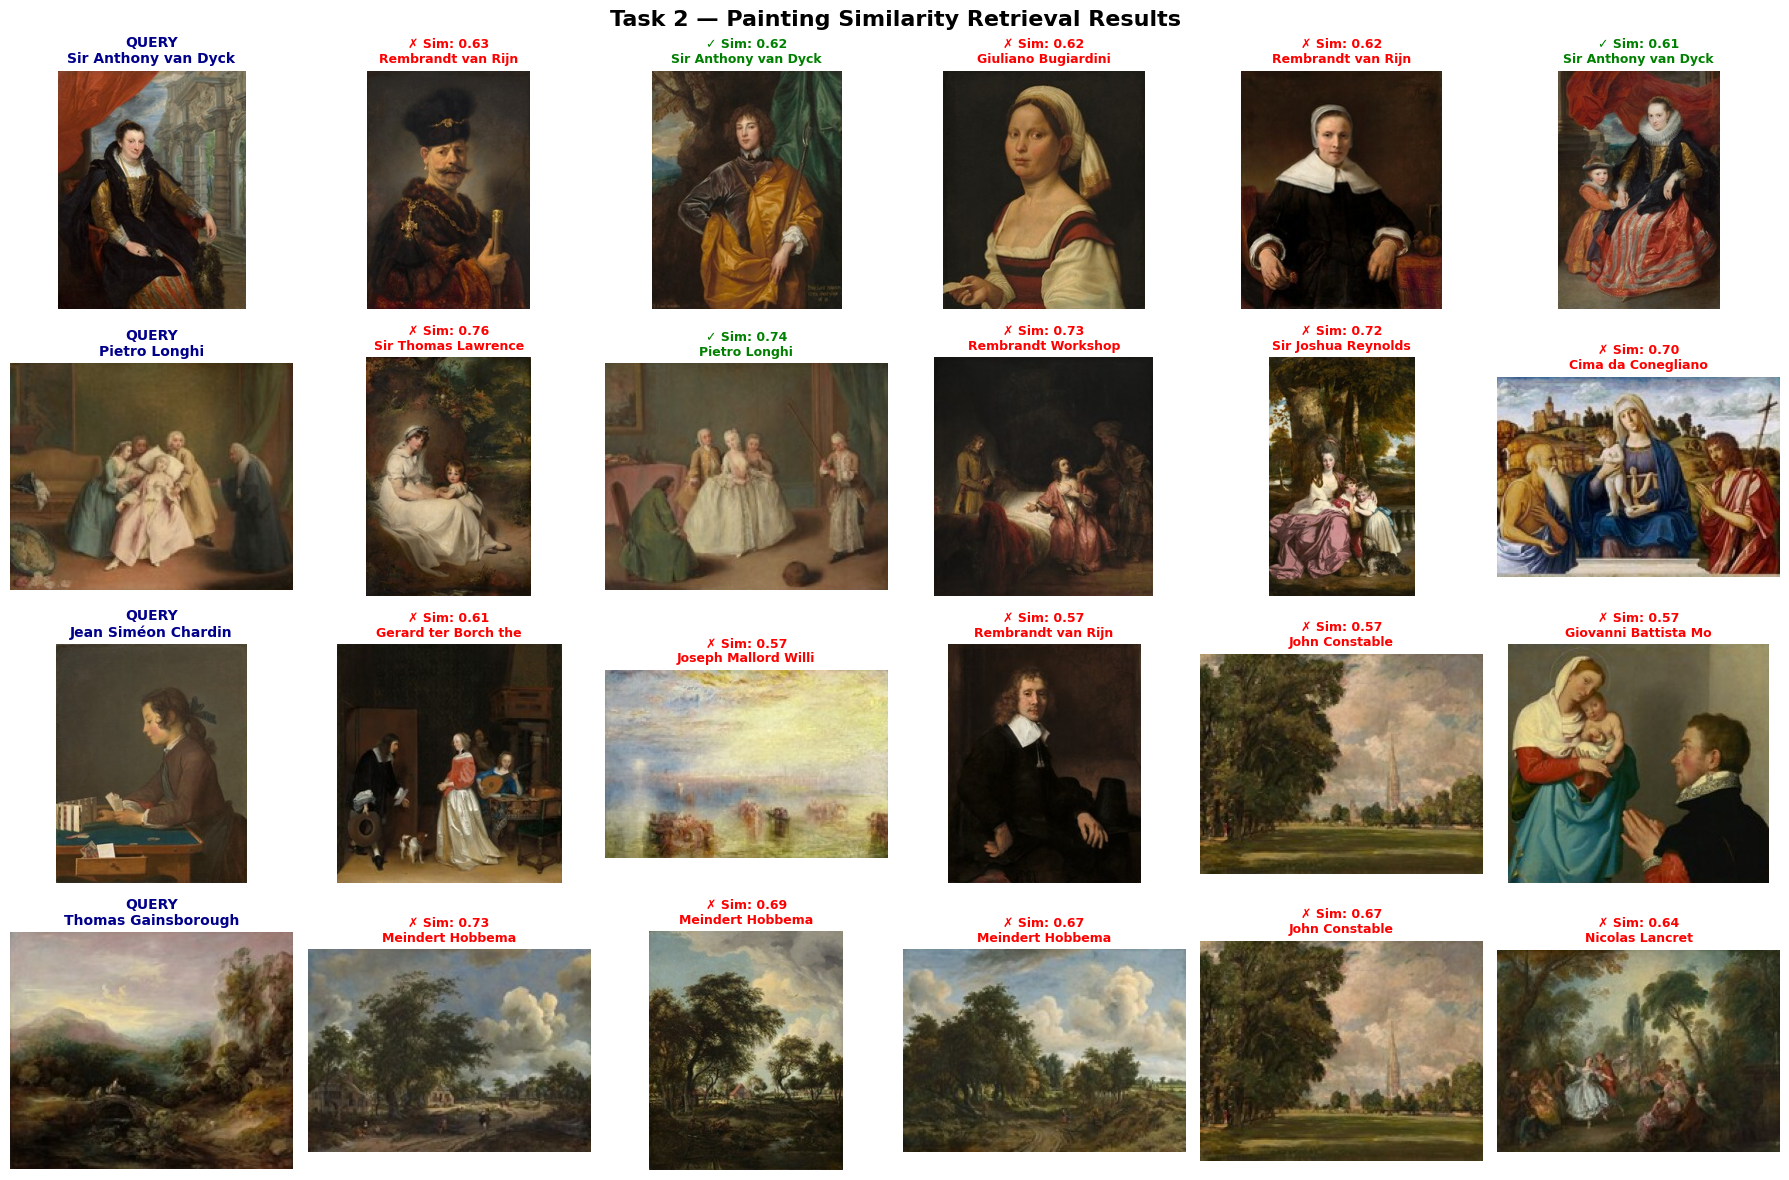

Evaluation complete! You can save this plot for your proposal.


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
import torch

# 1. Put model in evaluation mode
task2_model.eval()

test_embeddings = []
test_labels = []
test_images = []

print("Extracting embeddings for KNN retrieval...")
with torch.no_grad():
    for sample in nga_samples:
        # Transform image and move to device
        img_t = sim_transform(sample['image']).unsqueeze(0).to(DEVICE)

        # Get embedding
        emb = task2_model(img_t).cpu().numpy()[0]

        test_embeddings.append(emb)
        test_labels.append(sample['artist'])
        test_images.append(sample['image'])

test_embeddings = np.array(test_embeddings)
test_labels = np.array(test_labels)

# 2. Fit K-Nearest Neighbors
# We ask for K+1 because the closest match will always be the image itself (distance 0)
K_RETRIEVALS = 5
knn = NearestNeighbors(n_neighbors=K_RETRIEVALS + 1, metric='cosine')
knn.fit(test_embeddings)

distances, indices = knn.kneighbors(test_embeddings)

# 3. Visualize the Results for a few random queries
N_QUERIES = 4
fig, axes = plt.subplots(N_QUERIES, K_RETRIEVALS + 1, figsize=(18, 12))

# Pick random images to act as our "Search Queries"
query_indices = np.random.choice(len(test_images), N_QUERIES, replace=False)

for row, q_idx in enumerate(query_indices):
    # Plot the Query Image
    axes[row, 0].imshow(test_images[q_idx])
    axes[row, 0].set_title(f"QUERY\n{test_labels[q_idx][:20]}",
                           fontsize=10, fontweight='bold', color='darkblue')
    axes[row, 0].axis('off')

    # Plot the Top-K Retrieved Images
    retrieved_idx = indices[q_idx, 1:] # Skip the 0th index (which is the query itself)
    retrieved_dist = distances[q_idx, 1:]

    for col, (r_idx, dist) in enumerate(zip(retrieved_idx, retrieved_dist)):
        ax = axes[row, col + 1]
        ax.imshow(test_images[r_idx])

        # Check if the retrieved painting is by the same artist
        is_match = (test_labels[r_idx] == test_labels[q_idx])
        color = 'green' if is_match else 'red'
        marker = '✓' if is_match else '✗'

        # Cosine distance to Cosine Similarity
        sim_score = 1 - dist

        ax.set_title(f"{marker} Sim: {sim_score:.2f}\n{test_labels[r_idx][:20]}",
                     fontsize=9, color=color, fontweight='bold')
        ax.axis('off')

fig.suptitle('Task 2 — Painting Similarity Retrieval Results', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("Evaluation complete! You can save this plot for your proposal.")